<div style="width: 100%; height: 5px; background-color: green;"></div>
Here we load ENCODEC token files from a Hugging Face dataset.
To understand them better, we do some analysis and visualization of the code sequences 
as well as the 128D vector sequences - comparing those latents reconstructed from tokens with those encoded from audio.
<div style="width: 100%; height: 5px; background-color: green;"></div>

In [1]:
from datasets import load_dataset, load_from_disk, Audio
from transformers import EncodecModel, AutoProcessor

In [2]:
import librosa
import torch
import os
import numpy as np

In [3]:
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import random

<div style="width: 100%; height: 20px; background-color: green;"></div>
<b>Parameters</b>

In [4]:
dspath='/slowdisk/esteban/scratchdata/syntex24/data7wav/syn7wav24_tokens_HFdataset_5'
sample_rate = 24000  #must match the encodec model as well as the audio signals encoded
sample_class=7 # This will cause a random sound from this class to be used. See Class Name Mapping below

In [5]:
# Load your dataset (Hugging Face dataset and API)
dataset = load_from_disk(dspath)  # Use your wav dataset (has the mapping)

In [6]:
# Extract unique class mappings
class_mapping = {}
for split_name in dataset.keys():
    for sample in dataset[split_name]:
        class_name = sample['class_name']
        class_index = sample['param0']
        class_mapping[class_name] = class_index
        
# Create reverse mapping (index → class name)
index_to_class = {v: k for k, v in class_mapping.items()}

print("\nIndex → Class Name Mapping:")
for index in sorted(index_to_class.keys()):
    print(f"  {index}: {index_to_class[index]}")


Index → Class Name Mapping:
  1: ChirpPattern
  2: DSApplause
  3: DSBugs
  4: DSPeepers
  5: DSPistons
  6: DSWind
  7: TokWotalDuet


<div style="width: 100%; height: 20px; background-color: green;"></div>
<b>Helper functions</b>

In [7]:
def get_random_sample_by_class(dataset, class_index, split='val'):
    """
    Get a random sample index for a given class
    
    Args:
        dataset: HuggingFace dataset
        class_index: The param0 value (1-7) to search for
        split: Which split to search in ('train', 'train_sm', 'val')
    
    Returns:
        int: Random sample index with that class, or None if not found
    """
    # Find all indices with the given class
    matching_indices = [
        i for i, sample in enumerate(dataset[split]) 
        if sample['param0'] == class_index
    ]
    
    if not matching_indices:
        print(f"No samples found with class index {class_index} in {split} split")
        return None
    
    # Return random index from matches
    return random.choice(matching_indices)

In [8]:
def load_and_examine_tokens(dspath, sample_idx=0):
    """Load dataset and examine a specific sample
    
    Returns
    sample, audio_codes, audio_scales, padding_mask
    sample - the data structure containing the record for indexed sample
    audio_codes - [1,8,T] assuming 8 tokens per frame were stored
    audio_scales - probably None since the 24kHz model doesn't normalize by chunk (doesn't chunk at all)
    padding_mask - also not relevant for the 24kHz model
    """
    
    # Load the token dataset
    print("Loading token dataset...")
    ds = load_from_disk(dspath)['val']
    print(f"Validation set has {len(ds)} samples")
    
    # Get a sample
    sample = ds[sample_idx]
    print(f"\nExamining sample {sample_idx}:")
    print(f"  File: {sample['audio']}")
    print(f"  Class: {sample['class_name']}")
    print(f"  Param0: {sample['param0']}")
    
    # Load the token sequence with encoder outputs
    token_path = os.path.join(dspath, sample['audio'])
    saved_data = torch.load(token_path)
    
    # Extract the data in the new simplified format
    audio_codes = saved_data['audio_codes']
    audio_scales = saved_data['audio_scales'] 
    audio_length = saved_data['audio_length']
    
    # Create padding mask from the stored audio length
    padding_mask = torch.zeros(1, audio_length, dtype=torch.bool)
    
    print("  ✅ Loaded encoder outputs")
    print(f"  Audio codes shape: {audio_codes.shape}")
    print(f"  Audio scales type: {type(audio_scales)}")
    if isinstance(audio_scales, list):
        print(f"  Audio scales list length: {len(audio_scales)}")
        if len(audio_scales) > 0 and hasattr(audio_scales[0], 'shape'):
            print(f"  Audio scales[0] shape: {audio_scales[0].shape}")
    else:
        print(f"  Audio scales shape: {audio_scales.shape}")
    print(f"  Audio length: {audio_length}")
    print(f"  Padding mask shape: {padding_mask.shape}")
    
    # Handle different possible shapes for display
    if audio_codes.dim() == 4:
        # Shape [1, 1, n_q, time] -> [1, n_q, time] 
        audio_codes = audio_codes.squeeze(1)
    elif audio_codes.dim() == 2:
        # Shape [n_q, time] -> add batch dimension
        audio_codes = audio_codes.unsqueeze(0)
    
    print(f"  Token shape for analysis: {audio_codes.shape}")  # Should be [1, 8, 375] for 6kbps
    print(f"  Number of codebooks: {audio_codes.shape[1]}")
    print(f"  Sequence length: {audio_codes.shape[2]}")
    
    return sample, audio_codes, audio_scales, padding_mask
    
# ------------------------------------------------------------------------------------
def plot_first_codebook(audio_codes, sample):
    """Plot the sequence of the first codebook"""
    # audio_codes shape: [1, 8, 375] -> get first codebook across time
    first_codebook = audio_codes[0, 0, :].cpu().numpy()  # [375] - first codebook across time
    
    plt.figure(figsize=(12, 4))
    plt.plot(first_codebook, 'b-', linewidth=0.8, alpha=0.7, marker='o', markersize=2)
    plt.title(f'First Codebook (0) Token Sequence - {sample["class_name"]}')
    plt.xlabel('Time Frame')
    plt.ylabel('Token ID')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"First codebook stats:")
    print(f"  Sequence length: {len(first_codebook)}")
    print(f"  Min token: {first_codebook.min()}")
    print(f"  Max token: {first_codebook.max()}")
    print(f"  Unique tokens: {len(np.unique(first_codebook))}")
    print(f"  Token range: {first_codebook.max() - first_codebook.min()}")

# ------------------------------------------------------------------------------------
# reconstructs audios using different numbers of codebooks

def reconstruct_audio_progressive(audio_codes, audio_scales, padding_mask, model, codebook_counts=[2, 4, 8]):
    """Reconstruct audio using different numbers of codebooks"""
    
    reconstructions = {}
    
    for n_codebooks in codebook_counts:
        print(f"\nReconstructing with {n_codebooks} codebooks...")
        
        # Take first n codebooks and ensure batch dimension
        partial_codes = audio_codes[:, :n_codebooks, :].unsqueeze(0)  # Add batch dim
        
        # Ensure all tensors are on the same device as the model
        device = next(model.parameters()).device
        partial_codes = partial_codes.to(device)
        
        if isinstance(audio_scales, list):
            audio_scales_device = [scale.to(device) if hasattr(scale, 'to') else scale for scale in audio_scales]
        else:
            audio_scales_device = audio_scales.to(device) if hasattr(audio_scales, 'to') else audio_scales
            
        padding_mask_device = padding_mask.to(device)
        
        print(f"  Partial codes shape: {partial_codes.shape}")
        
        with torch.no_grad():
            audio_values = model.decode(partial_codes, audio_scales_device, padding_mask_device)[0]
            audio_array = audio_values.squeeze().cpu().numpy()
            
            print(f"  Output shape: {audio_array.shape}")
            print(f"  Audio length: {len(audio_array) / sample_rate:.2f} seconds")
            
            reconstructions[n_codebooks] = audio_array
    
    return reconstructions
    
# ------------------------------------------------------------------------------------
# one plot per audio in reconstructions

def plot_audio_comparisons(reconstructions, sample):
    """Plot waveforms for different codebook counts"""
    
    n_plots = len(reconstructions)
    fig, axes = plt.subplots(n_plots, 1, figsize=(12, 3*n_plots))
    
    if n_plots == 1:
        axes = [axes]
    
    colors = ['blue', 'red', 'green', 'purple', 'orange']
    
    for i, (n_codebooks, audio) in enumerate(reconstructions.items()):        
        time_axis = np.linspace(0, len(audio) / sample_rate, len(audio))
        
        axes[i].plot(time_axis, audio, color=colors[i % len(colors)], 
                    linewidth=0.5, alpha=0.8)
        axes[i].set_title(f'{n_codebooks} Codebooks - {sample["class_name"]}')
        axes[i].set_xlabel('Time (seconds)')
        axes[i].set_ylabel('Amplitude')
        axes[i].grid(True, alpha=0.3)
        
        # Add some stats
        rms = np.sqrt(np.mean(audio**2))
        axes[i].text(0.02, 0.95, f'RMS: {rms:.4f}', transform=axes[i].transAxes, 
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------------
# one spectrogram per audio in reconstructions

def plot_spectrograms(reconstructions, sample, sample_rate=24000):
    """Plot spectrograms for different codebook counts"""
    
    n_plots = len(reconstructions)
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 4))
    
    if n_plots == 1:
        axes = [axes]
    
    for i, (n_codebooks, audio) in enumerate(reconstructions.items()):
        # Compute spectrogram
        D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
        
        # Plot
        img = librosa.display.specshow(D, sr=sample_rate, x_axis='time', y_axis='hz', 
                                     ax=axes[i], cmap='viridis')
        axes[i].set_title(f'{n_codebooks} Codebooks')
        
        # Add colorbar
        plt.colorbar(img, ax=axes[i], format='%+2.0f dB')
    
    fig.suptitle(f'Spectrograms - {sample["class_name"]}', fontsize=14)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------------
# One Audio Control for each audio in reconstructions
                  
def create_audio_controls(reconstructions, sample, sample_rate=24000):
    """Create IPython Audio controls for listening"""
    
    print("\n" + "="*60)
    print("🎵 AUDIO PLAYBACK CONTROLS")
    print("="*60)
    
    for n_codebooks, audio in reconstructions.items():
        print(f"\n🎧 {n_codebooks} Codebooks ({sample['class_name']}):")
        print(f"   Audio length: {len(audio) / sample_rate:.2f} seconds")
        print(f"   RMS level: {np.sqrt(np.mean(audio**2)):.4f}")
        display(Audio(audio, rate=sample_rate))


In [9]:
# reconstruct the latents from the codes.
# The original model had a method for doing this, but they hid it for the Hugging Face version
# 
def efficient_codes_to_latents(model, codes):
    """
    Efficient version for repeated use (e.g., in DataLoaders)
    """
    model.eval()
    
    with torch.no_grad():
        # Direct quantizer access with proper transpose
        if codes.shape[0] == 1:  # batch dimension first
            codes_transposed = codes.transpose(0, 1)  # (n_q, batch, time) # Yep, batch second here. Someone broke protocol!
        else:
            codes_transposed = codes
            
        # Direct quantizer decode - this is just lookups + addition
        embeddings = model.quantizer.decode(codes_transposed)
        return embeddings


In [10]:
# Get the sequence of latents for a sequence of stacked tokens (audio_codes)
# Visualize them as heat maps

def analyze_128d_latents(audio_codes, audio_scales, padding_mask, model, n_codebooks=8, sample=None):
    """
    Reconstruct 128-D latent vectors from tokens and create waterfall plot
    
    Args:
        audio_codes: Token tensor [1, 8, time]
        model: EnCodec model
        n_codebooks: Number of codebooks to use
        sample: Sample metadata for title
    """
    
    print(f"\nAnalyzing 128-D latents with {n_codebooks} codebooks...")
    
    # Take first n codebooks
    partial_codes = audio_codes[:, :n_codebooks, :]  # [1, n, time]
    
    # Ensure tensor is on the same device as the model
    device = next(model.parameters()).device
    partial_codes = partial_codes.to(device)

    with torch.no_grad():
        # HF different from CodeCraft - no decode_talent method!!!
        # latent_embeddings = model.decode_latent(codes) # What we'd really like
        
        latent_embeddings = efficient_codes_to_latents(model, partial_codes)
        print(f' ==========   SHAPE of latent_embeddings is {latent_embeddings.shape}')
        
        # Remove batch dimension and convert to numpy
        latents = latent_embeddings.squeeze(0).cpu().numpy()  # [128, time]
        
    print(f"  Latent embeddings shape: {latents.shape}")
    print(f"  Time frames: {latents.shape[1]}")
    print(f"  Latent dimensions: {latents.shape[0]}")
    
    # Create waterfall plot
    plt.figure(figsize=(15, 8))
    
    # Plot as heatmap/waterfall
    im = plt.imshow(latents, aspect='auto', cmap='RdBu_r', interpolation='nearest')
    
    # Customize plot
    title = f'128-D Latent Vectors Over Time ({n_codebooks} codebooks)'
    if sample:
        title += f' - {sample["class_name"]}'
    plt.title(title, fontsize=14)
    
    plt.xlabel('Time Frame')
    plt.ylabel('Latent Dimension')
    plt.colorbar(im, label='Magnitude')
    
    # Add some statistics
    mean_magnitude = np.mean(np.abs(latents))
    max_magnitude = np.max(np.abs(latents))
    plt.text(0.02, 0.98, f'Mean |magnitude|: {mean_magnitude:.3f}\nMax |magnitude|: {max_magnitude:.3f}', 
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Plot magnitude over time (RMS across latent dimensions)
    plt.figure(figsize=(12, 4))
    rms_over_time = np.sqrt(np.mean(latents**2, axis=0))  # RMS across 128 dimensions for each time frame
    time_axis = np.arange(len(rms_over_time))
    
    plt.plot(time_axis, rms_over_time, 'b-', linewidth=1.5, alpha=0.8)
    plt.title(f'RMS Magnitude of 128-D Latents Over Time ({n_codebooks} codebooks)')
    plt.xlabel('Time Frame')
    plt.ylabel('RMS Magnitude')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Show some statistics
    print(f"\n📊 Latent Statistics:")
    print(f"  Mean magnitude: {mean_magnitude:.4f}")
    print(f"  Max magnitude: {max_magnitude:.4f}")
    print(f"  Min magnitude: {np.min(np.abs(latents)):.4f}")
    print(f"  Std magnitude: {np.std(latents):.4f}")
    print(f"  Dynamic range: {max_magnitude/np.mean(np.abs(latents)):.2f}x")
    
    return latents

<div style="width: 100%; height: 20px; background-color: green;"></div>
<b>Do it!</b>

In [11]:
# Setup model
print("Loading EnCodec model...")
model = EncodecModel.from_pretrained("facebook/encodec_24khz")
model.config.target_bandwidths = [6.0]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

print(f"Model training mode: {model.training}")

Loading EnCodec model...
Using device: cuda
Model training mode: False


Loading token dataset...
Validation set has 147 samples

Examining sample 141:
  File: val/TokWotalDuet--wmratio-00.80--c-00--x-00.ecdc
  Class: TokWotalDuet
  Param0: 7
  ✅ Loaded encoder outputs
  Audio codes shape: torch.Size([1, 1, 8, 375])
  Audio scales type: <class 'list'>
  Audio scales list length: 1
  Audio length: 120000
  Padding mask shape: torch.Size([1, 120000])
  Token shape for analysis: torch.Size([1, 8, 375])
  Number of codebooks: 8
  Sequence length: 375

📊 Plotting first codebook sequence...


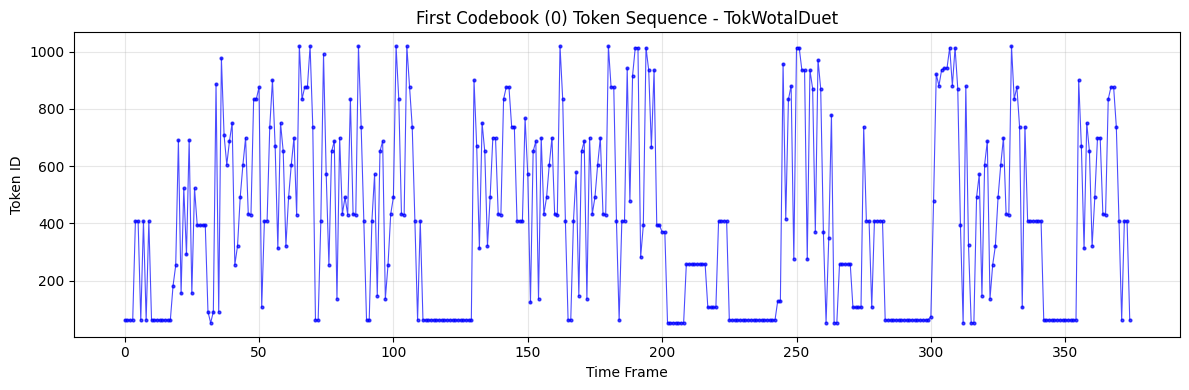

First codebook stats:
  Sequence length: 375
  Min token: 52
  Max token: 1019
  Unique tokens: 66
  Token range: 967


In [12]:
# Load, examine, visualize

sample_idx = get_random_sample_by_class(dataset, class_index=sample_class, split='val') 
sample, audio_codes, audio_scales, padding_mask = load_and_examine_tokens(dspath, sample_idx)

# Move data to same device as model  
audio_codes = audio_codes.to(device)
if isinstance(audio_scales, list):
    audio_scales = [scale.to(device) if hasattr(scale, 'to') else scale for scale in audio_scales]
elif hasattr(audio_scales, 'to'):
    audio_scales = audio_scales.to(device)
padding_mask = padding_mask.to(device)

# Plot first codebook
print(f"\n📊 Plotting first codebook sequence...")
plot_first_codebook(audio_codes.cpu(), sample)  # Move to CPU for plotting

In [13]:
# sample, audio_codes, audio_scales, padding_mask = load_and_examine_tokens(dspath, sample_idx)
# audio_scales


🔊 Reconstructing audio...

Reconstructing with 2 codebooks...
  Partial codes shape: torch.Size([1, 1, 2, 375])
  Output shape: (120000,)
  Audio length: 5.00 seconds

Reconstructing with 4 codebooks...
  Partial codes shape: torch.Size([1, 1, 4, 375])
  Output shape: (120000,)
  Audio length: 5.00 seconds

Reconstructing with 8 codebooks...
  Partial codes shape: torch.Size([1, 1, 8, 375])
  Output shape: (120000,)
  Audio length: 5.00 seconds

📈 Plotting waveform comparisons...


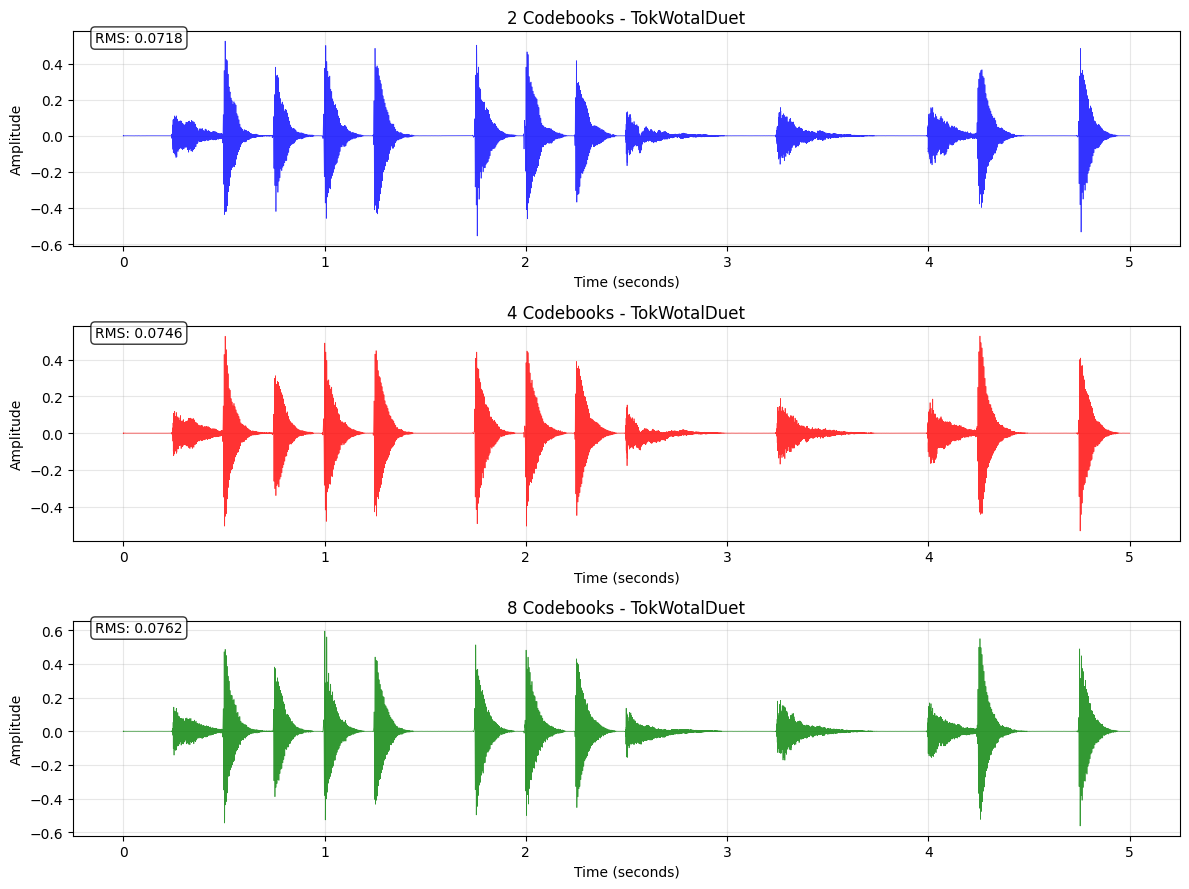

In [14]:
# Reconstruct with different codebook counts
print(f"\n🔊 Reconstructing audio...")
reconstructions = reconstruct_audio_progressive(audio_codes, audio_scales, padding_mask, model, [2, 4, 8])#[2, 4, 8])

# Plot comparisons
print(f"\n📈 Plotting waveform comparisons...")
plot_audio_comparisons(reconstructions, sample)



📊 Plotting spectrograms...


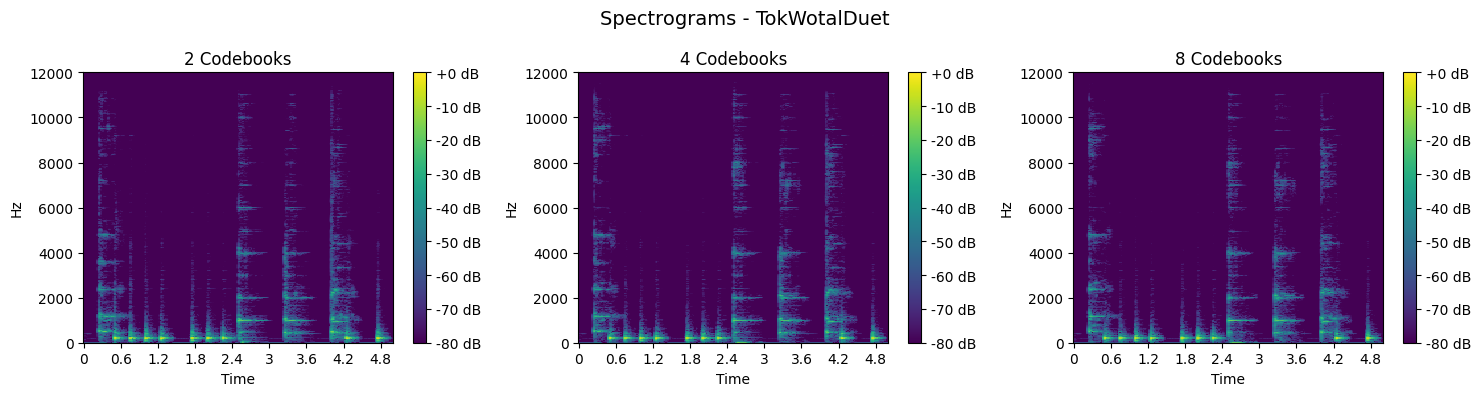


🎵 AUDIO PLAYBACK CONTROLS

🎧 2 Codebooks (TokWotalDuet):
   Audio length: 5.00 seconds
   RMS level: 0.0718



🎧 4 Codebooks (TokWotalDuet):
   Audio length: 5.00 seconds
   RMS level: 0.0746



🎧 8 Codebooks (TokWotalDuet):
   Audio length: 5.00 seconds
   RMS level: 0.0762


In [15]:
    print(f"\n📊 Plotting spectrograms...")
    plot_spectrograms(reconstructions, sample)
    
    # Audio controls
    create_audio_controls(reconstructions, sample)


🔬 Analyzing 128-D latent vectors...

Analyzing 128-D latents with 8 codebooks...
 ==========   SHAPE of latent_embeddings is torch.Size([1, 128, 375])
  Latent embeddings shape: (128, 375)
  Time frames: 375
  Latent dimensions: 128


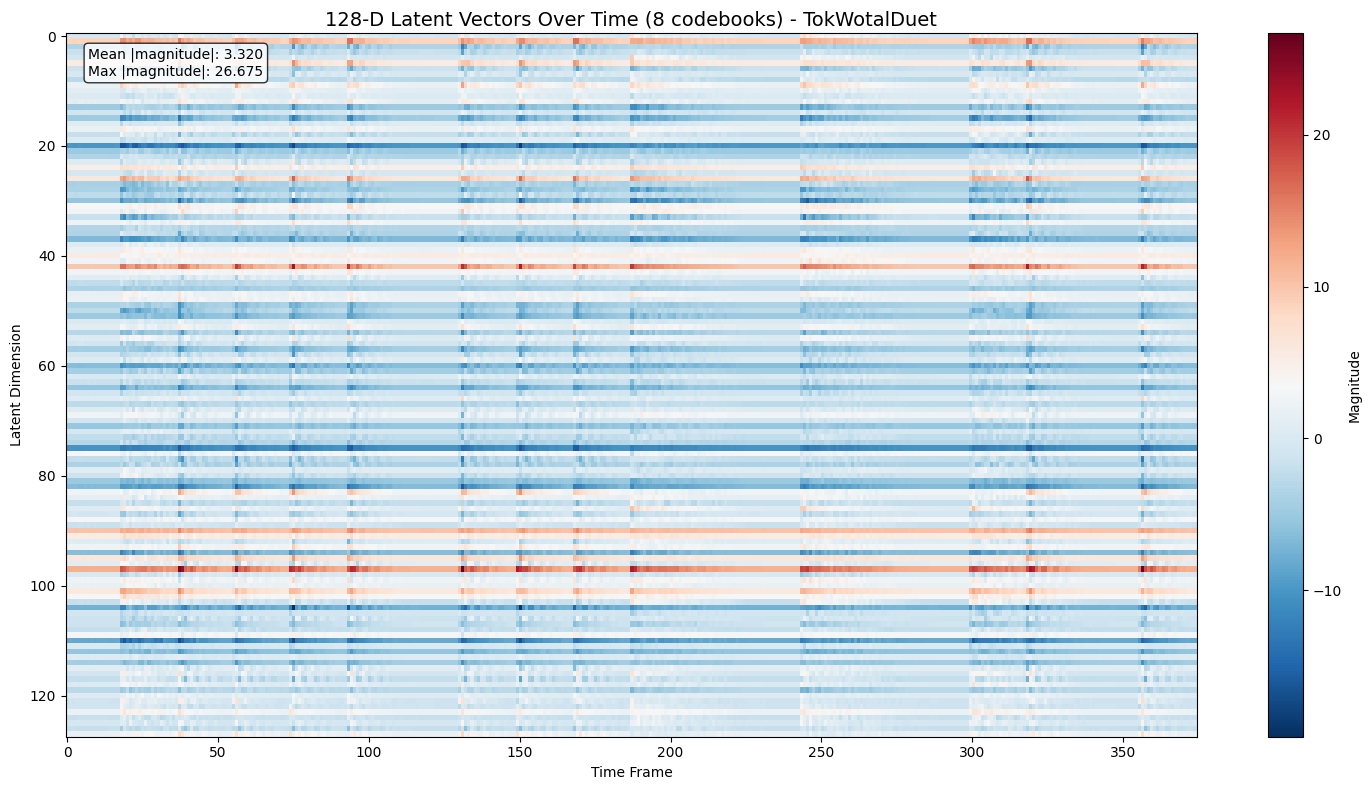

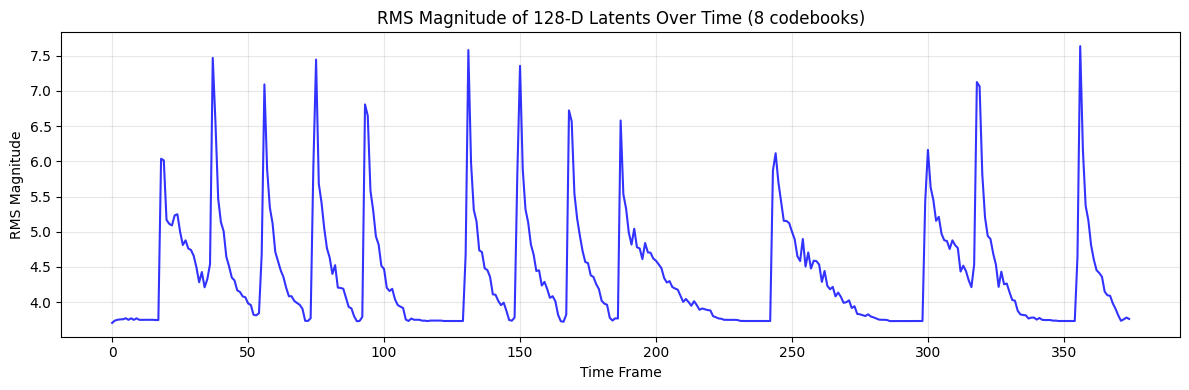


📊 Latent Statistics:
  Mean magnitude: 3.3197
  Max magnitude: 26.6749
  Min magnitude: 0.0001
  Std magnitude: 4.4274
  Dynamic range: 8.04x


In [16]:
# Analyze 128-D latents
print(f"\n🔬 Analyzing 128-D latent vectors...")
latents = analyze_128d_latents(audio_codes, audio_scales, padding_mask, model, n_codebooks=8, sample=sample)



🔬 Comparing with fewer codebooks...

Analyzing 128-D latents with 4 codebooks...
 ==========   SHAPE of latent_embeddings is torch.Size([1, 128, 375])
  Latent embeddings shape: (128, 375)
  Time frames: 375
  Latent dimensions: 128


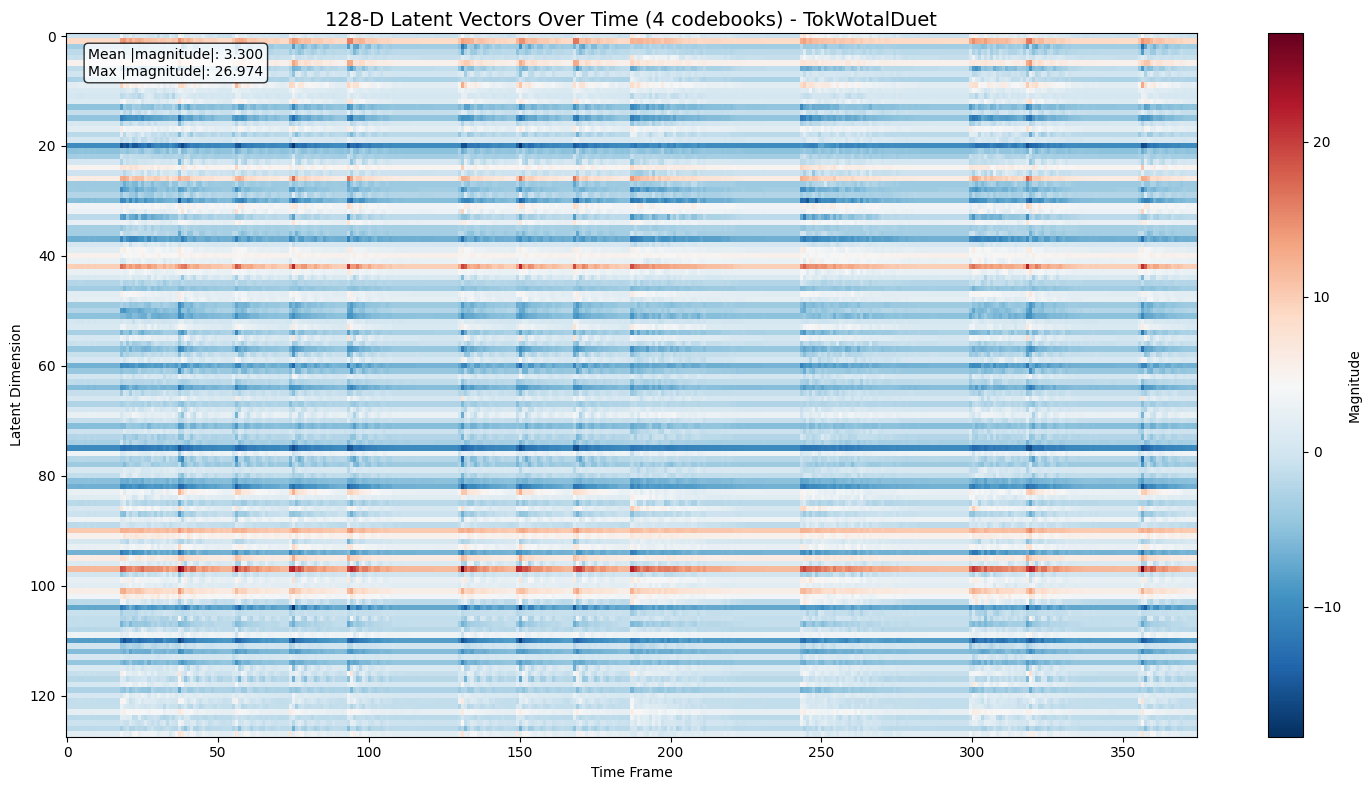

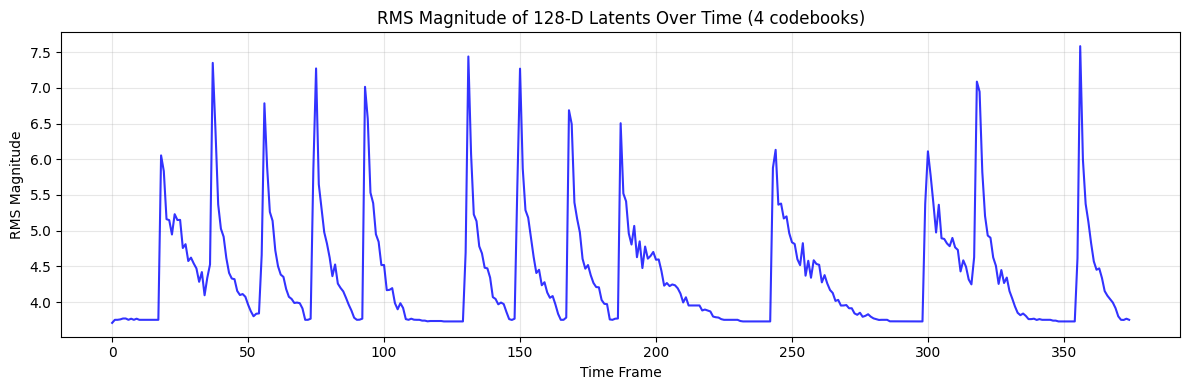


📊 Latent Statistics:
  Mean magnitude: 3.3003
  Max magnitude: 26.9743
  Min magnitude: 0.0002
  Std magnitude: 4.4046
  Dynamic range: 8.17x


In [17]:
# You can also analyze with fewer codebooks to compare
print(f"\n🔬 Comparing with fewer codebooks...")
###latents_4cb = analyze_128d_latents(audio_codes, model, n_codebooks=4, sample=sample)
latents_4cb = analyze_128d_latents(audio_codes, audio_scales, padding_mask, model, n_codebooks=4, sample=sample)

<div style="width: 100%; height: 20px; background-color: green;"></div>
<b>OK, the heatmaps and mag plots are for LATENTS mapped from CODES. The should very close to the same if we decode all the way back to audio and then encode to the continuous latents. Let's see...</b>

In [18]:
def encode_audio_to_latents(audio_dict, model, processor, sample_rate=24000):
    """
    Encode reconstructed audio to continuous 128-D latents (before quantization)
    
    Args:
        audio_dict: Dictionary from reconstruct_audio_progressive() {2: audio_array, 4: audio_array, 8: audio_array}
        model: EnCodec model
        processor: EnCodec processor  
        sample_rate: Audio sample rate
    """
    
    print("Encoding reconstructed audio to continuous 128-D latents...")
    
    latents_dict = {}
    
    for n_codebooks, audio_array in audio_dict.items():
        print(f"\nProcessing {n_codebooks}-codebook reconstruction...")
        
        # Pre-process the audio using the processor
        inputs = processor(raw_audio=audio_array, sampling_rate=sample_rate, return_tensors="pt")
        
        # Move to same device as model
        device = next(model.parameters()).device
        inputs = {k: v.to(device) for k, v in inputs.items()}

        print(f"---------Model training mode: {model.training}")
        with torch.no_grad():
            # Get the continuous latents from the encoder (before quantization)
            continuous_latents = model.encoder(inputs["input_values"])  # [1, 128, time]
            
            # Remove batch dimension
            latents = continuous_latents.squeeze(0).cpu().numpy()  # [128, time]
            
        print(f"  Continuous latents shape: {latents.shape}")
        latents_dict[n_codebooks] = latents
        
        # Plot waterfall for this reconstruction
        plt.figure(figsize=(15, 6))
        im = plt.imshow(latents, aspect='auto', cmap='RdBu_r', interpolation='nearest')
        plt.title(f'Continuous 128-D Latents from {n_codebooks}-Codebook Reconstructed Audio')
        plt.xlabel('Time Frame')
        plt.ylabel('Latent Dimension')
        plt.colorbar(im, label='Magnitude')
        
        # Add statistics
        mean_mag = np.mean(np.abs(latents))
        max_mag = np.max(np.abs(latents))
        plt.text(0.02, 0.98, f'Mean |mag|: {mean_mag:.3f}\nMax |mag|: {max_mag:.3f}', 
                 transform=plt.gca().transAxes, verticalalignment='top',
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
        # Plot RMS over time
        plt.figure(figsize=(12, 3))
        rms_over_time = np.sqrt(np.mean(latents**2, axis=0))
        plt.plot(rms_over_time, 'b-', linewidth=1.5)
        plt.title(f'RMS Magnitude Over Time ({n_codebooks} codebooks - continuous latents)')
        plt.xlabel('Time Frame')
        plt.ylabel('RMS Magnitude')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    return latents_dict

Encoding reconstructed audio to continuous 128-D latents...

Processing 2-codebook reconstruction...
---------Model training mode: False
  Continuous latents shape: (128, 375)


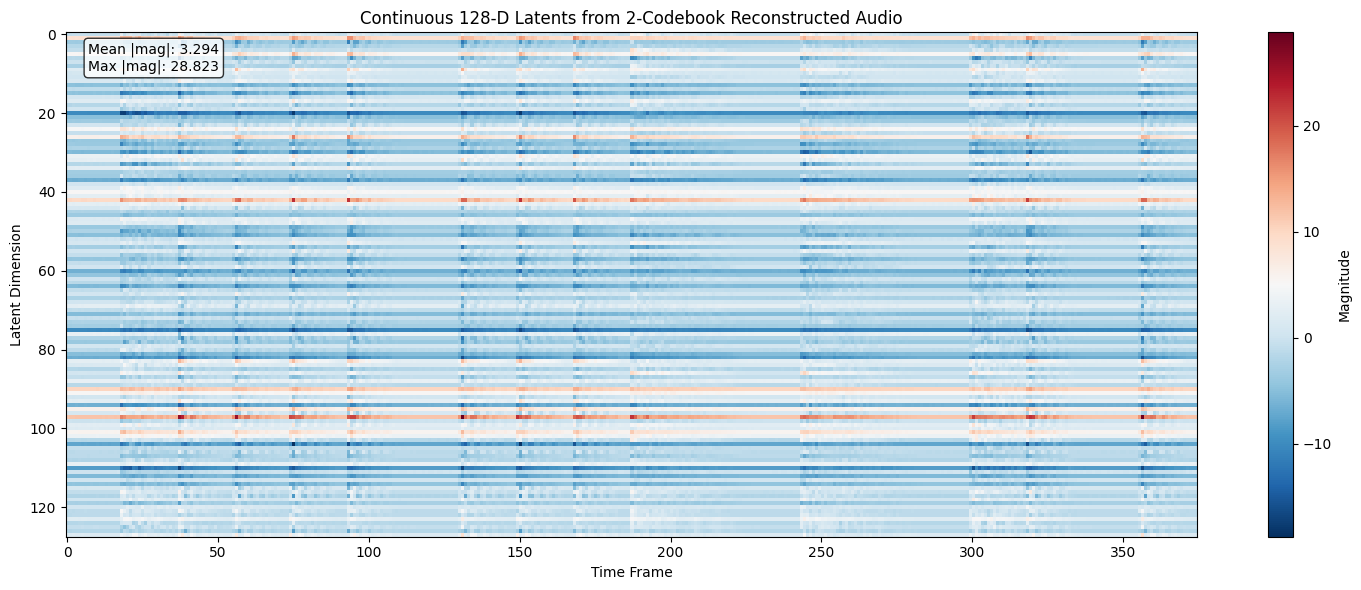

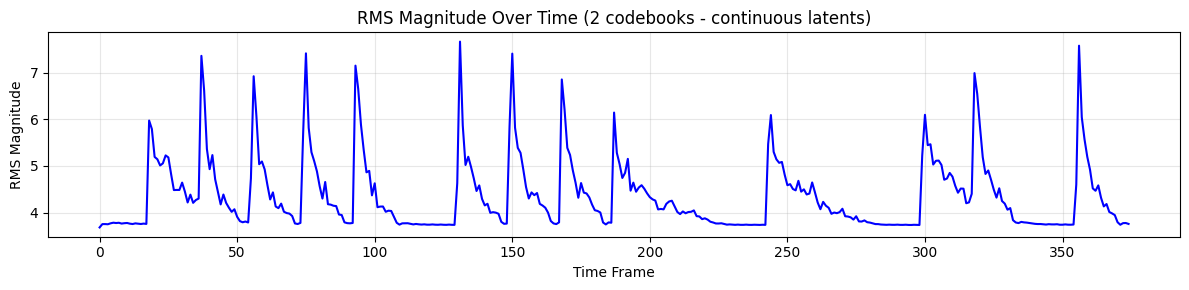


Processing 4-codebook reconstruction...
---------Model training mode: False
  Continuous latents shape: (128, 375)


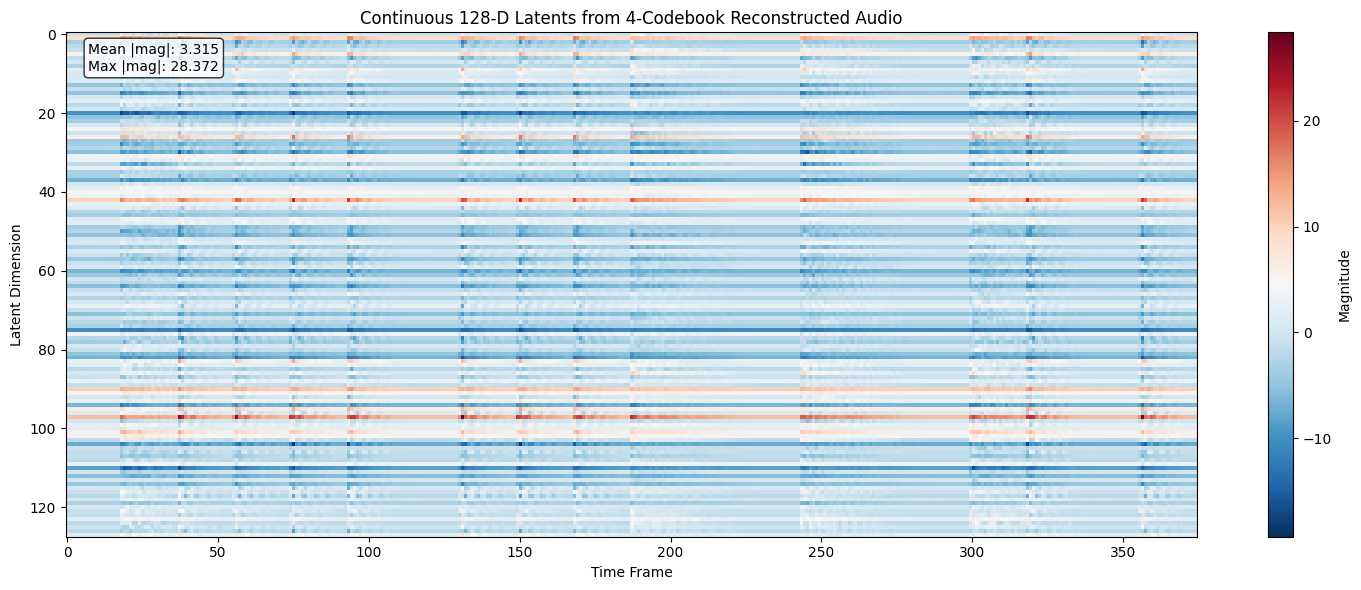

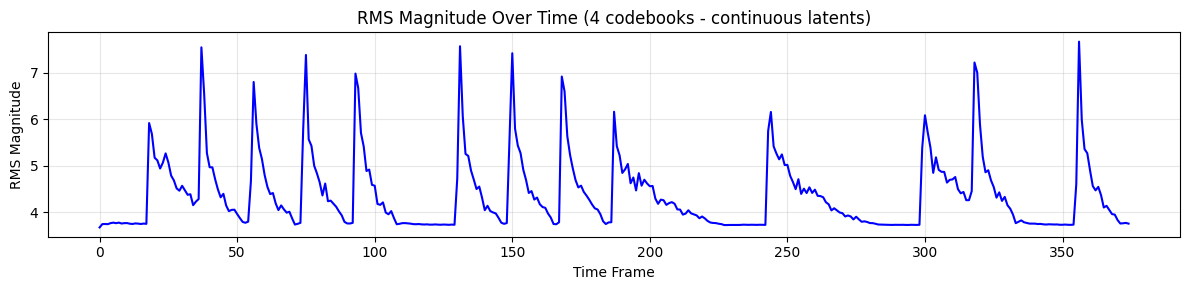


Processing 8-codebook reconstruction...
---------Model training mode: False
  Continuous latents shape: (128, 375)


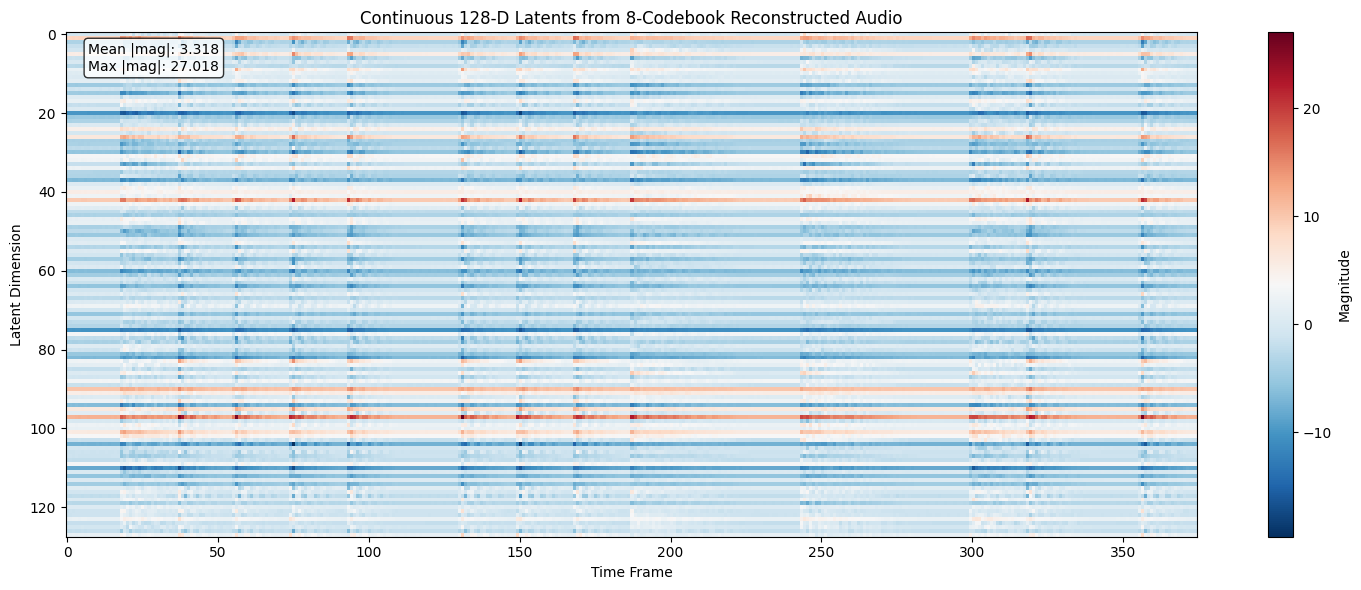

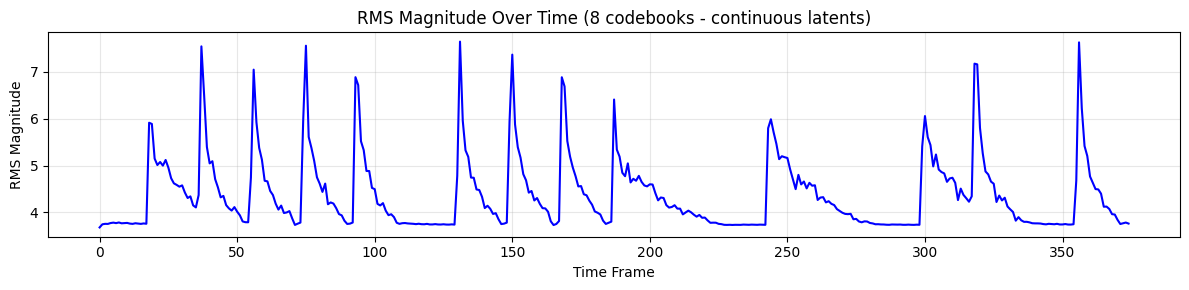

In [19]:
# Now lets take the reconstructed audio, and encode to the latents
# The should be pretty close to those we got from the codes
reconstructed_latents = encode_audio_to_latents(reconstructions, model, AutoProcessor.from_pretrained("facebook/encodec_24khz", use_fast=False))